## This just tests the non-dimensionalized direct integration of the SDE for x(t)

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial

from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

jax.config.update("jax_enable_x64", True)

In [2]:
# ----------------------------
# 1. Define Parameters
# ----------------------------

# Physical Constants and Parameters
M = 1.0
w_0 = 30.0          # Natural frequency (rad/s)
w_p = 2*w_0      # Driving frequency (rad/s), near 2*w_0 for w_p resonance
F_p = 8.      # Amplitude of the w_p driving
Qual = 200.0
GAMMA = w_0/(2*Qual)
gamma = 0*10*.05*1.0              # Nonlinearity coefficient (Duffing term)

k_B = 1.0             # Boltzmann's constant (arbitrary units for simulation)
T = 0.000000030             # Temperature (K)
D =  0*GAMMA*k_B * T/M      # Noise strength

args = (M, w_0, w_p,Qual, gamma, F_p)



# Simulation Parameters
t0 = 0.0  
num_periods = 500# Start time
t1 = num_periods*((2*jnp.pi)/w_0)
dt0 = 0.001
num_pts_per_period = 10000
ts_dim = jnp.linspace(t0, t1, num_periods*num_pts_per_period)

# Initial Conditions
x0 = 0.75*1e-7               # Initial displacement
v0 = 0.0               # Initial velocity
y0_x = jnp.array([x0, v0])


CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [3]:
# ----------------------------
# 2. Define SDEs
# ----------------------------

# 2.1. Direct Integration SDE for x(t)
def drift_x_fn(t, state, args):
    """
    Drift function for the direct integration of x(t).
    y = [x, v]
    """
    M, w_0, w_p, Qual, gamma, F_p = args
    x, v = state
    dxdt = v
    dvdt =  -w_0/Qual * v -  (w_0**2 -F_p/M * jnp.cos(w_p * t)) * x - gamma * x**3 
    return jnp.array([dxdt, dvdt])

def diffusion_x_fn(t, state, args):
    """
    Diffusion 
    """
    return jnp.array([0.0, D])

In [4]:
N = 2  
w_shape = (N,)  # state is (x1, p1)
brownian_motion = diffrax.VirtualBrownianTree(
    t0, t1, 0.0005, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)

In [5]:

terms_x = MultiTerm(ODETerm(drift_x_fn), ControlTerm(diffusion_x_fn, brownian_motion))
# Define the time points for sampling

saveat = diffrax.SaveAt(ts=ts_dim)


# sample 1000 points
solution_x = diffrax.diffeqsolve(
    terms_x,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_x,
    args=args,
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=10000000,
    # stepsize_controller=PIDController(rtol=rtol, atol=atol),
)
sde_samples_x = solution_x.ys[:, :N]


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

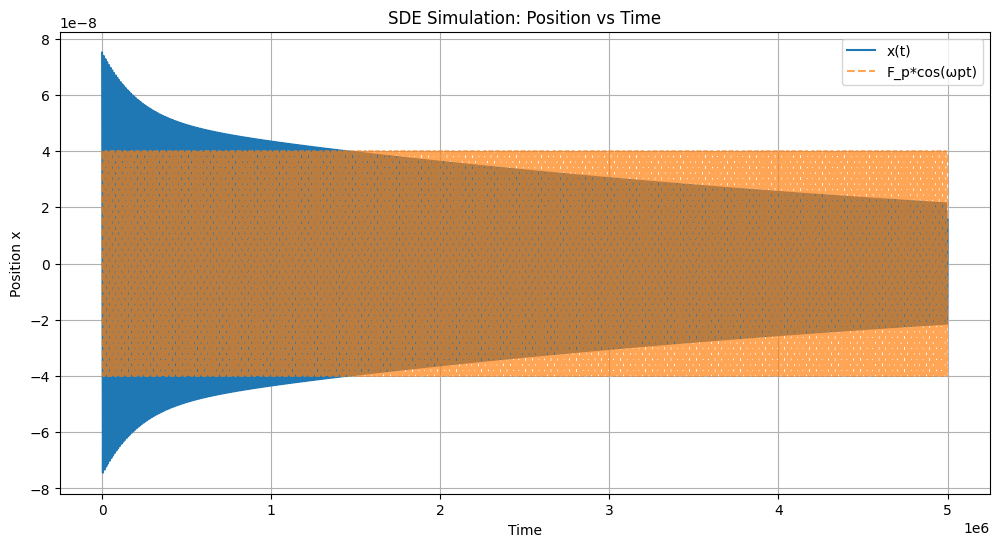

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(sde_samples_x[:, 0], label='x(t)')
plt.plot(4 * 1e-8 * jnp.cos(w_0 * ts_dim), '--', label='F_p*cos(ωpt)', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Position x')
plt.title('SDE Simulation: Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

In [7]:
def Hamiltonian(t,Q, P, args):
    M, w_0, w_p, GAMMA, gamma, F_p = args
    dw = w_p/2 - w_0
    return 3*gamma/(16*w_p) * (Q**2 + P**2)**2 + dw/2 *(Q**2 - P**2) +  F_p/(4*M*w_p) * (P**2 - Q**2)


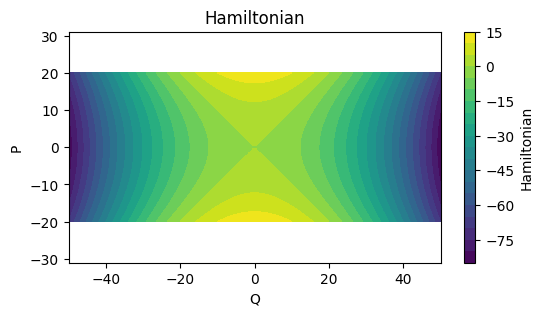

In [17]:
# Plot the Hamiltonian
Q_range = jnp.linspace(-50, 50, 100)
P_range = jnp.linspace(-20, 20, 100)
# Create meshgrid for Q and P
Q_mesh, P_mesh = jnp.meshgrid(Q_range, P_range)

# Vectorize Hamiltonian over both Q and P meshgrids
H_values = jax.vmap(lambda q, p: jax.vmap(lambda qi, pi: Hamiltonian(0.,qi, pi, args))(q, p))(Q_mesh, P_mesh)


plt.figure(figsize=(6, 3))
plt.contourf(Q_range, P_range, H_values, levels=20, cmap='viridis')
plt.axis('equal')
plt.colorbar(label='Hamiltonian')
plt.xlabel('Q')
plt.ylabel('P')
plt.title('Hamiltonian')
plt.show()


In [9]:
def Hamiltonian_effective_linear(t,Q, P, args):
    M, w_0, w_p, _, gamma, F_p = args
    return 1/2*Q**2-F_p/(2*w_p)/GAMMA*Q*P + 1/2*P**2

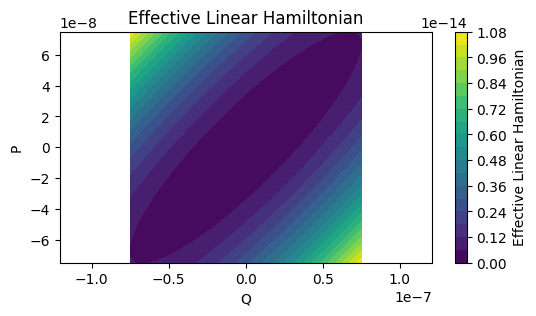

In [16]:
# Plot the Hamiltonian
Q_range = jnp.linspace(-50, 50, 100)*1e-9*1.5
P_range = jnp.linspace(-50, 50, 100)*1e-9*1.5
# Create meshgrid for Q and P
Q_mesh, P_mesh = jnp.meshgrid(Q_range, P_range)

# Vectorize Hamiltonian over both Q and P meshgrids
H_effective_linear_values = jax.vmap(lambda q, p: jax.vmap(lambda qi, pi: Hamiltonian_effective_linear(0.,qi, pi, args))(q, p))(Q_mesh, P_mesh)


plt.figure(figsize=(6, 3))
plt.contourf(Q_range, P_range, H_effective_linear_values, levels=20, cmap='viridis')
plt.colorbar(label='Effective Linear Hamiltonian')
plt.axis('equal')
plt.xlabel('Q')
plt.ylabel('P')
plt.title('Effective Linear Hamiltonian')
plt.show()


In [11]:
# # 2.2. Amplitude Equations SDEs for A_r(t) and A_i(t)
# def drift_QP_fn(t, state, args):
#     """
#     Drift function for the amplitude equations.
#     A = [A_r, A_i]
#     """
#     _, w_0, _, Qual, _, _ = args
#     Q, P = state
        
#     H = lambda _Q, _P: Hamiltonian(t,_Q, _P, args)
    
#     dQdt =  jax.grad(H, 1)(Q, P) - w_0/(2*Qual)*Q
#     dPdt = -jax.grad(H, 0)(Q, P) - w_0/(2*Qual)*P
    
#     # Drift terms
#     return jnp.array([dQdt, dPdt])

def drift_QP_fn(t, state, args):
    """
    Drift function for the amplitude equations.
    A = [A_r, A_i]
    """
    _, w_0, _, Qual, _, _ = args
    Q, P = state
        
    H_linear = lambda _Q, _P: Hamiltonian_effective_linear(t,_Q, _P, args)
    
    dQdt = -GAMMA*jax.grad(H_linear, 0)(Q, P) 
    dPdt = -GAMMA*jax.grad(H_linear, 1)(Q, P) 
    
    # Drift terms
    return jnp.array([dQdt, dPdt])


def diffusion_QP_fn(t, state, args):
    """
    Diffusion 
    """
    return jnp.array([D/(M*w_0**2), D/(M*w_0**2)])

In [12]:
N = 2  # (x1, x2)
w_shape = (N,)  # state is (x1, x2, p1, p2)
brownian_motion = diffrax.VirtualBrownianTree(
    t0, t1, 0.0005, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)

y0_QP = jnp.array([x0, 0.0])

terms_QP = MultiTerm(ODETerm(drift_QP_fn), ControlTerm(diffusion_QP_fn, brownian_motion))

saveat = diffrax.SaveAt(ts=ts_dim)

solution_QP = diffrax.diffeqsolve(
    terms_QP,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_QP,
    args=args,
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=10000000,
    # stepsize_controller=diffrax.PIDController(rtol=rtol, atol=atol),
)
sde_samples_QP = solution_QP.ys[:, :N]



100.00%|##########| [00:03<00:00, 30.67%/s]


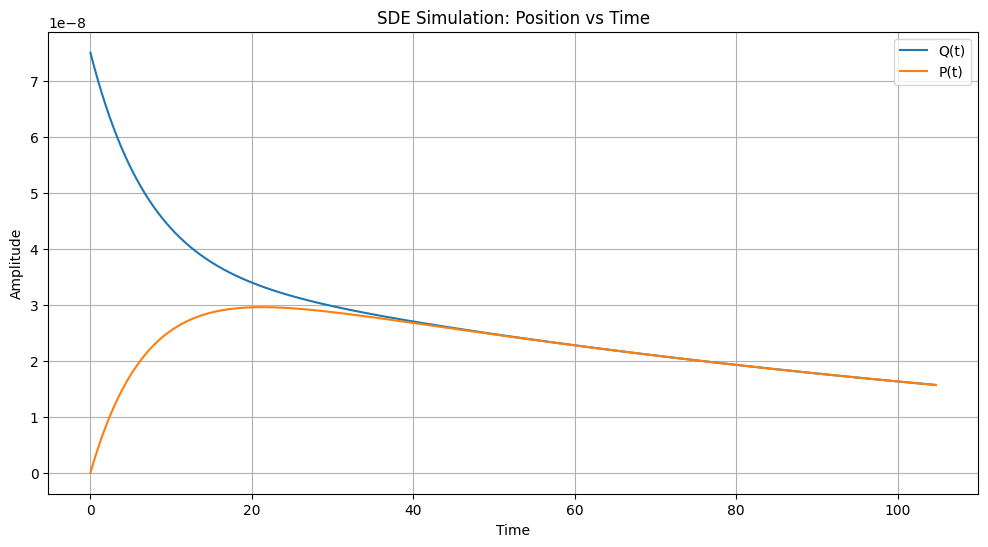

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(ts_dim, sde_samples_QP[:, 0], label='Q(t)')
plt.plot(ts_dim, sde_samples_QP[:, 1], label='P(t)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('SDE Simulation: Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

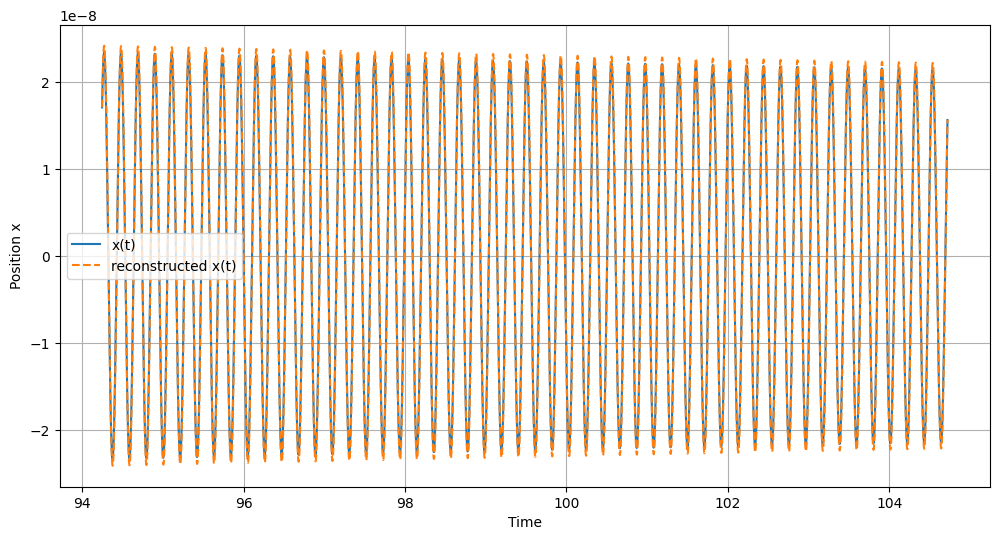

In [14]:
def reconstruct_x(t, Q, P):
    """
    Reconstruct x(t) from Q(t) and P(t).
    """
    return Q * jnp.cos(w_0 * t) + P * jnp.sin(w_0 * t)

id_start = -500000
id_end = -1

plt.figure(figsize=(12, 6))
plt.plot(ts_dim[id_start:id_end],sde_samples_x[id_start:id_end, 0], label='x(t)')
plt.plot(ts_dim[id_start:id_end],reconstruct_x(ts_dim[id_start:id_end], sde_samples_QP[id_start:id_end, 0], sde_samples_QP[id_start:id_end  , 1]), '--', label='reconstructed x(t)')
plt.xlabel('Time')
plt.ylabel('Position x')
# plt.title(f'Reconstructed x(t) from Q(t) and P(t) - L2 Loss: {l2_diff:.6f}')
plt.grid(True)
plt.legend()
plt.show()

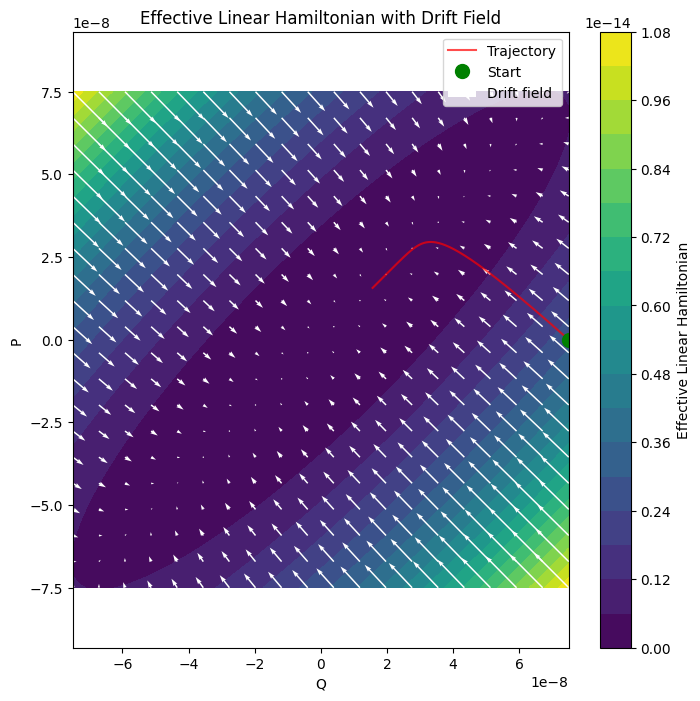

In [15]:
# Create contour plot with fixed square aspect ratio
plt.figure(figsize=(8, 8))  # Make figure square

# Create contour plot
plt.contourf(Q_range, P_range, H_effective_linear_values, levels=20, cmap='viridis')
plt.colorbar(label='Effective Linear Hamiltonian')

# Add trajectory
plt.plot(sde_samples_QP[:, 0], sde_samples_QP[:, 1], 'r-', label='Trajectory', alpha=0.7)
plt.plot(sde_samples_QP[0, 0], sde_samples_QP[0, 1], 'go', label='Start', markersize=10)

# Create a coarser grid for the gradient vectors
n_arrows = 20
Q_arrows = jnp.linspace(Q_range.min(), Q_range.max(), n_arrows)
P_arrows = jnp.linspace(P_range.min(), P_range.max(), n_arrows)
QQ, PP = jnp.meshgrid(Q_arrows, P_arrows)

# Evaluate drift terms on the grid
drift_vals = jax.vmap(lambda q, p: drift_QP_fn(0., jnp.array([q, p]), args))(QQ.flatten(), PP.flatten())
dQ = drift_vals[:, 0].reshape(QQ.shape)
dP = drift_vals[:, 1].reshape(PP.shape)

# Scale the arrows for better visualization
scale = 5e-8*3  # Adjust this value to make arrows more visible
plt.quiver(QQ, PP, dQ, dP, scale=scale, color='white', alpha=1., label='Drift field')

plt.xlabel('Q')
plt.ylabel('P')
plt.title('Effective Linear Hamiltonian with Drift Field')
plt.legend()

# Force equal aspect ratio
plt.axis('equal')

# Ensure the limits are symmetric and match the data range
max_range = max(abs(Q_range.max()), abs(P_range.max()))
plt.xlim(-max_range, max_range)
plt.ylim(-max_range, max_range)

plt.show()